In [3]:
import json
import os
import random
import sys
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

In [4]:
MODULES_PATH = Path("../modules").resolve()

if str(MODULES_PATH) not in sys.path:
    sys.path.insert(0, str(MODULES_PATH))

import corpus
import api

from dev import rel, print_epi_summary
from data_config import DATA_CONFIG, FEW_SHOT_PATH
from few_shot import get_few_shot_examples
from error_sampling import error_summary, sample_errors
from plotting import plot_dist_comparison

import pipeline

# Config.

### Development Config.

In [5]:
load_dotenv()

# ---------- Set seed to 42 ----------
SEED = int(os.getenv("SEED", 42))
random.seed(SEED)

# ---------- Print confirmation ----------
print(
    f"Set random seed to {SEED} at "
    f"{datetime.now().strftime('%Y-%m-%d %H:%M')}"
)

Set random seed to 42 at 2026-08-24 19:52


### EPI Config.

In [108]:
# ---------- Manual EPI config. entry ----------
EPI_NUM = "009"
DATASET_SPLIT = "train"

# ---------- Config. whether EPI config's API should be called again ----------
CALL_API = True

# ---------- Config. whether error distribution figure should be saved ----------
SAVE_FIG = True

# Corpus Loading

### Load Abstracts

In [109]:
# ---------- Get abstracts path ----------
ABSTRACTS_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["abstracts"]
SAMPLE_SIZE = DATA_CONFIG[DATASET_SPLIT]["sample_size"]

# ---------- Load corpus from path ----------
abstracts_corpus = corpus.load_corpus(ABSTRACTS_PATH, sample_size=SAMPLE_SIZE)
print(f"Abstracts dataset length: {len(abstracts_corpus)}")

Abstracts dataset length: 400


### Get Ground Truths

In [110]:
# ---------- Manually Set Ground Truth Paths ----------
GT_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["ground_truths"]
ENTITIES_GT_PATH = DATA_CONFIG[DATASET_SPLIT]["paths"]["entities_ground_truths"]

# ---------- Fetch BioRED Ground Truths ----------
abstracts_ground_truths = corpus.get_corpus_gt_csv(abstracts_corpus, GT_PATH)
entities_ground_truths = corpus.get_corpus_gt_csv(abstracts_corpus, ENTITIES_GT_PATH)

In [111]:
entities_ground_truths.head()

,pmid,entity_id,text,entity_type,identifier,start,end,split
0,10491763,0,Hepatocyte nuclear factor-6,GeneOrGeneProduct,3175,0,27,train
1,10491763,1,type II diabetes,DiseaseOrPhenotypicFeature,D003924,74,90,train
2,10491763,2,insulin,GeneOrGeneProduct,3630,140,147,train
3,10491763,3,hepatocyte nuclear factor (HNF)-6,GeneOrGeneProduct,3175,184,217,train
4,10491763,4,maturity-onset diabetes,DiseaseOrPhenotypicFeature,D003924,292,315,train


In [112]:
abstracts_ground_truths.head()

,pmid,entity_1,entity_1_type,entity_1_identifier,relation,entity_2,entity_2_type,entity_2_identifier,split
0,10491763,Hepatocyte nuclear factor-6,GeneOrGeneProduct,3175,Association,type II diabetes,DiseaseOrPhenotypicFeature,D003924,train
1,10491763,glucose,ChemicalEntity,D005947,Positive_Correlation,insulin,GeneOrGeneProduct,3630,train
2,10491763,glucose,ChemicalEntity,D005947,Association,type II diabetes,DiseaseOrPhenotypicFeature,D003924,train
3,10661407,Langerin,GeneOrGeneProduct,50489,Bind,mannose,ChemicalEntity,D008358,train
4,10788334,breast or ovarian cancer,DiseaseOrPhenotypicFeature,D001943,Positive_Correlation,5382insC,SequenceVariant,c|INS|5382|C,train


In [113]:
entities_ground_truths["entity_type"].unique()

<StringArray>
[         'GeneOrGeneProduct', 'DiseaseOrPhenotypicFeature',
             'ChemicalEntity',              'OrganismTaxon',
            'SequenceVariant',                   'CellLine']
Length: 6, dtype: str

In [114]:
os.getcwd()

'e:\\Users\\wesle\\biomedical_kg_thesis\\src\\experiments'

In [115]:
# ---------- Turn ground truth DataFrame into structured dict ----------
ground_truths = corpus.get_gt_dict(abstracts_ground_truths, entities_ground_truths)

### Few-Shot Construction

In [116]:
# ---------- If FS block does not exist, create FS block, else pass ----------
if not os.path.exists(FEW_SHOT_PATH):

    few_shot_block = get_few_shot_examples(
        path_to_train_set=DATA_CONFIG["train"]["paths"]["abstracts"],
        path_to_train_gts=DATA_CONFIG["train"]["paths"]["ground_truths"],
        biored_train_samples=abstracts_corpus,
        few_shot_export_path=FEW_SHOT_PATH
    )
    print(f"Generated and exported new few-shot block to '{FEW_SHOT_PATH}'")
else:
    with open(FEW_SHOT_PATH) as f:
        few_shot_block = f.read()
    print(f"Imported existing few-shot block from '{FEW_SHOT_PATH}' at {datetime.now().strftime('%Y-%m-%d %H:%M')}.")

Imported existing few-shot block from '../../data/few_shot/few_shot_block.txt' at 2026-08-25 14:15.


### Import BioRED Extraction Guidelines

In [117]:
# ---------- Import BioRED guidelines text file for prompt refinement ----------
with open("../../data/processed/biored/guidelines.txt", "r", encoding="utf-8") as f:
    biored_ext_guidelines = f.read()

# ---------- Print preview ----------
print(f"{biored_ext_guidelines[:500]}...")

## Guideline of the entities

### General rules
- Annotate all the spans of all the six concept types.
- The full text can be accessed to clarify the concept spans and identifiers.
- The abbreviation and its long form should be annotated separately if possible. prostaglandin E2 (PGE2) in the text, “prostaglandin E2” and “PGE2” should be both annotated to chemicals with the same identifier (D015232).
- Annotate both the full name and abbreviation in one entity, if the boundary of the entity cover...


# OpenAI Luna API Call

### EPI Setup

In [118]:
# ---------- Create EPI setup dictionary ----------
# - Keys: "dataset", "id", "eval_version", "notes", "reuse_api_call", "prompt"
epi_setup = pipeline.setup_epi(EPI_NUM, DATASET_SPLIT)

# ---------- Print summary ----------
print_epi_summary(
    epi_num=EPI_NUM,
    prompt_version=epi_setup["prompt"]["version"],
    eval_version=epi_setup["eval_version"],
    notes=epi_setup["notes"],
    reuse_api_call=epi_setup["reuse_api_call"]
)

Cell ran at 2026-08-25 14:15 for epi_009
 - Prompt version: v8
 - Evaluation version: v4
 - Notes: Targeted suppression of residual relation over-extraction through entity-pair evidence constraints.
 - Reuse API Call: False


### API Call

In [ ]:
# ---------- API call / import existing EPI API log ----------
if CALL_API:
    # ---------- Create client ----------
    client = api.create_client(timeout=120, max_retries=2)

    # ---------- If prompt version is different from previous EPI, call API, else pass ----------
    if not epi_setup["reuse_api_call"]:

        print(f"Running API call for {epi_setup["id"]} ({epi_setup["dataset"]})...")

        # Fetch raw prompt template
        prompt_template = epi_setup["prompt"]["template"]

        # Begin timer
        start_time = time.perf_counter()

        # Initiate outputs list
        outputs = []

        current_abstract_num = 1

        # Begin looping through abstract dataset rows - one call per row
        for index, row in abstracts_corpus.iterrows():
            abstract = row["abstract"]
            title = row["title"]

            num_abstracts = abstracts_corpus.shape[0]

            # Replace prompt template's placeholders with abstract, few_shot & guidelines
            prompt = (
                prompt_template
                .replace("{title}", title)
                .replace("{abstract}", abstract)
                .replace("{few_shot_block}", few_shot_block)
                .replace("{biored_ext_guidelines}", biored_ext_guidelines)
            )

            # Store row's response
            response = client.responses.create(
                model="gpt-5.6-luna",
                input=prompt
            )

            # Append response to outputs list
            outputs.append({
                "pmid": row["pmid"],
                "output": response.output_text
            })

            progress_time = time.perf_counter() - start_time
            avg_time_per_abstract = progress_time / current_abstract_num
            est_time_remaining = avg_time_per_abstract * (num_abstracts - current_abstract_num)
            minutes = int(est_time_remaining // 60)
            seconds = est_time_remaining % 60

            print(
                f"\rCompleteled extraction for abstract {current_abstract_num} of {num_abstracts} "
                f"({current_abstract_num / num_abstracts * 100:.1f}%; "
                f"Est. time remaining: {minutes}m {seconds:.0f}s).",
                end="",
                flush=True
            )
            current_abstract_num += 1

        # End time, store elapsed time & print result
        elapsed_seconds = time.perf_counter() - start_time
        print(f"\n\nAPI calls took {elapsed_seconds:.1f}s ({elapsed_seconds/60:.1f} min) for {len(outputs)} abstracts\n")

        print(f"Successfully ran API call at {datetime.now().strftime('%Y-%m-%d %H:%M')}")
        print(f" - Prompt verion: {epi_setup["prompt"]["version"]}")
        print(f" - Evalaution verion: {epi_setup["eval_version"]}")
        print(f" - Run notes: {epi_setup["notes"]}")
        print(f" - Elapsed time: {elapsed_seconds:.1f}s ({elapsed_seconds/60:.1f})")
    else:
        prev_epi_id = f"epi_{int(EPI_NUM) - 1:03d}"

        with open(f"{DATA_CONFIG[DATASET_SPLIT]["paths"]["epi_dir"]}/{prev_epi_id}.json") as f:
            prev_epi_log = json.load(f)

        outputs = prev_epi_log["outputs"]
        prompt_template = prev_epi_log["prompt"]
        elapsed_seconds = prev_epi_log["time_taken"]

        print(f"Reused API call from {prev_epi_id}.")

    output_info = {
        "epi_id": epi_setup["id"],
        "outputs": outputs,
        "time_taken": elapsed_seconds,
        "raw_prompt": prompt_template,
        "epi_notes": epi_setup["notes"],
        "prompt_version": epi_setup["prompt"]["version"],
        "eval_version": epi_setup["eval_version"],
        "export_path": DATA_CONFIG[DATASET_SPLIT]["paths"]["epi_dir"]
    }
else:
    print(f"Pipeline run not executed at {datetime.now().strftime('%Y-%m-%d %H:%M')} (PIPELINE_RUN = False).")

Created client:
 - Timeout: 120
 - Max retries: 2

Running API call for epi_009 (biored_train)...
Completeled extraction for abstract 254 of 400 (63.5%; Est. time remaining: 56m 26s)..

In [ ]:
# ---------- Parse outputs, evaluate extractions, export EPI results ----------
if CALL_API:
    epi_log = pipeline.process_epi(output_info, ground_truths, dataset=epi_setup["dataset"])
else:
    print(f"Pipeline run not executed at {datetime.now().strftime('%Y-%m-%d %H:%M')} ('CALL_API = False').")

Parsed 400 extractions, 0 failed to parse as JSON
Saved epi_008 to ../../data/results/epis/biored_train


# Error Analysis

### Summary Table

In [ ]:
# ---------- If EPI API call does not exist in kernel state, import existing EPI log ----------
if not CALL_API:
    try:
        with open(f"../../data/results/epis/{epi_setup["dataset"]}/{epi_setup["id"]}.json") as f:
            epi_log = json.load(f)
    except:
        raise ValueError(
            f"EPI log cannot be imported: "
            f"'../../data/results/epis/{epi_setup["dataset"]}/{epi_setup["id"]}.json' does not exist."
        )

error_summary(epi_log)

`epi_008` Error Summary:


Metric,Precision,Recall,F1
Entity,0.913,0.743,0.819
Relation,0.519,0.489,0.504


### Distribution Comparison

Saved figure to `../../img/extraction_distribution/biored_train` successfully.


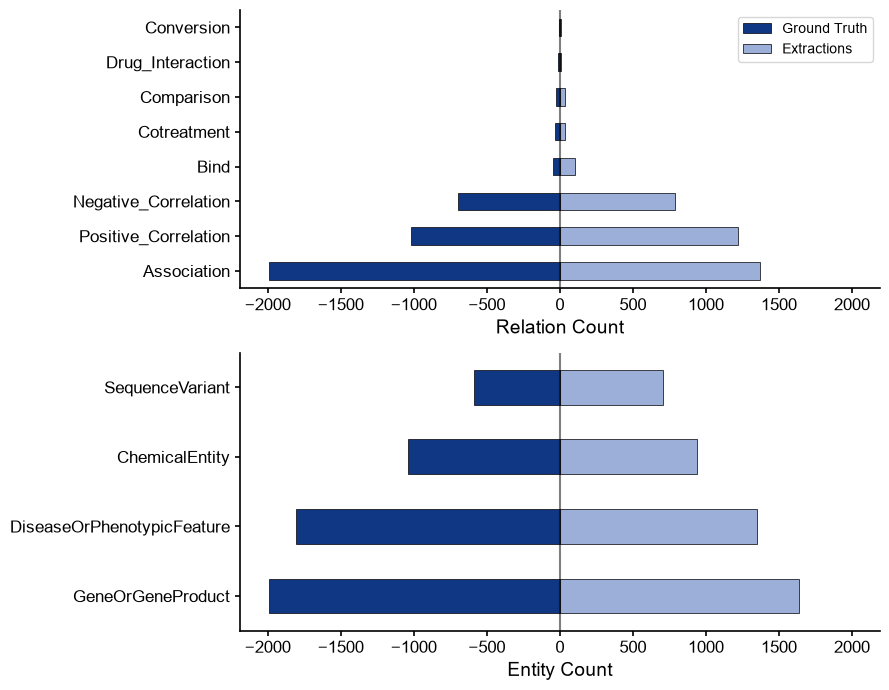

In [ ]:
if EPI_NUM == "001":
    print(
        "Extraction distribution analaysis is not conducted on 'epi_001' - "
        "extractions are not bound to fixed sets."
    )
elif epi_setup["reuse_api_call"] == True:
    print(
        f"EPI uses previous EPI's prompt - "
        f"did not plot ground truth/extraction distribution figure for `epi_{EPI_NUM}`."
    )
else:
    plot_dist_comparison(epi_log, ground_truths, save=SAVE_FIG)


## Relations

### False Positives

In [ ]:
if DATASET_SPLIT == "train":
    # ---------- False positives ----------
    relation_fp = epi_log["errors"]["errors"]["relations"]["false_positives"]

    print(f"Count: {len(relation_fp)}")

    display(sample_errors(relation_fp, sample_size=200))

Count: 1734
Sample size: 200


[[19889778, 'tenofovir', 'Positive_Correlation', 'rtm204i'],
 [16309808, 'mirtazapine', 'Cotreatment', 'domperidone'],
 [19642243, 'tenofovir', 'Positive_Correlation', 'renal failure'],
 [19728177, 'fulminant hepatic failure', 'Association', 'cerebral edema'],
 [18945288, 'p.arg58fs', 'Association', 'alkaptonuria'],
 [16810074, 'lnna', 'Positive_Correlation', 'et-1'],
 [28468941, 'smad1/5/8', 'Positive_Correlation', 'hyperproliferation'],
 [20534142, 'pcsk1', 'Positive_Correlation', 'childhood obesity'],
 [16157158, '5-ht(2c)', 'Association', 'cys 23-ser 23'],
 [7668252, 'vlcad', 'Association', 'vlcad deficiency'],
 [15122708, 'mb-drms', 'Association', 'mallory body-like inclusions'],
 [19508969, 'p.g821r', 'Association', 'mks3/tmem67'],
 [18483878, 'vip', 'Negative_Correlation', 'il-1beta'],
 [17250663, 'p.d572h', 'Comparison', 'p.d572n'],
 [25622904, 'fbxw7', 'Bind', 'sag'],
 [18270997, 'g472a', 'Association', 'opiate addiction'],
 [15122711, 'glu873stop', 'Association', 'polg'],
 [2

### False Negatives

In [ ]:
if DATASET_SPLIT == "train":
    # ---------- False negatives ----------
    relation_fn = epi_log["errors"]["errors"]["relations"]["false_negatives"]

    print(f"Count: {len(relation_fn)}")

    display(sample_errors(relation_fn, sample_size=200))

Count: 1959
Sample size: 200


[[18366737, 'fh', 'Association', 'encephalopathy'],
 [7905839, 'mu opiate receptor', 'Association', 'opioid peptides'],
 [26516699, 'pancreatic cancer', 'Association', 'mir-216a'],
 [21238926, 'brat', 'Association', 'nanos'],
 [18442015, 'luminal', 'Positive_Correlation', 'gastric hemorrhagic ulcers'],
 [20534142, 'insulin', 'Association', 'proinsulin'],
 [22303482, 'tbx21', 'Association', 'tnf-a'],
 [27084744, 'g-secretase', 'Negative_Correlation', 'p27kip1'],
 [24477591,
  'reactive oxygen species',
  'Association',
  'coronary artery disease'],
 [20005218, 'g-395a', 'Positive_Correlation', 'essential hypertension'],
 [28260110,
  'fatty acid synthase',
  'Association',
  'mitogen-activated protein kinases/extracellular signal-regulated kinases 1/2'],
 [25979836, 'cck', 'Association', 'small-gtpases'],
 [21070631, 'inflammatory', 'Association', 'il6'],
 [25622904, 'sag', 'Association', 'p21'],
 [25263533, 'bcl6', 'Negative_Correlation', 'igg'],
 [15145918,
  'alpha-methyldopa',
  'Po

## Entities

### False Positives

In [ ]:
if DATASET_SPLIT == "train":
    # ---------- False positives ----------
    entities_fp = epi_log["errors"]["errors"]["entities"]["false_positives"]

    print(f"Count: {len(entities_fp)}")

    display(sample_errors(entities_fp))

Count: 432
Sample size: 20


[[27860244, 'tnf-a', 'ChemicalEntity'],
 [28851297, 'rs368698783', 'SequenceVariant'],
 [18699851, 't(11;14)(q13;q32)', 'SequenceVariant'],
 [19082493, 'c_allele 6-', 'SequenceVariant'],
 [18439317, 'lumbar disc disease', 'DiseaseOrPhenotypicFeature'],
 [18768591, 'epithelial sodium channel', 'GeneOrGeneProduct'],
 [15755837, 'reduced folate forms', 'ChemicalEntity'],
 [24853300, 'ab', 'ChemicalEntity'],
 [17318851, 'tooth agenesis', 'DiseaseOrPhenotypicFeature'],
 [16575011, '3r/-6 base pair (bp) haplotype', 'SequenceVariant'],
 [20606392, 'gh', 'ChemicalEntity'],
 [15184369, 'trpv6', 'GeneOrGeneProduct'],
 [17277899, 'apo', 'SequenceVariant'],
 [24623966, 'oir', 'DiseaseOrPhenotypicFeature'],
 [15614572, 'penile erections', 'DiseaseOrPhenotypicFeature'],
 [17854040, 'rt', 'GeneOrGeneProduct'],
 [16720068, 'diazepam', 'ChemicalEntity'],
 [15970799, 'slco1b1*1b', 'SequenceVariant'],
 [19889778, 'sp120t', 'SequenceVariant'],
 [19082493, 'g_allele6-', 'SequenceVariant']]

### False Negatives

In [ ]:
if DATASET_SPLIT == "train":
    # ---------- False negatives ----------
    entities_fn = epi_log["errors"]["errors"]["entities"]["false_negatives"]

    print(f"Count: {len(entities_fn)}")

    display(sample_errors(entities_fn))

Count: 1563
Sample size: 20


[[8755918, 'patients', 'OrganismTaxon'],
 [18809400, 'mitochondrial toxicity', 'DiseaseOrPhenotypicFeature'],
 [15649253, 'tumor', 'DiseaseOrPhenotypicFeature'],
 [15278670, 'convulsive', 'DiseaseOrPhenotypicFeature'],
 [19508969, 'cerebellar anomalies', 'DiseaseOrPhenotypicFeature'],
 [17439425, 'reactive oxygen species', 'ChemicalEntity'],
 [25983002, 'tumor', 'DiseaseOrPhenotypicFeature'],
 [16596970, 'humans', 'OrganismTaxon'],
 [21080147, 'heart defect', 'DiseaseOrPhenotypicFeature'],
 [18593936, 'angiogenic proteins', 'GeneOrGeneProduct'],
 [20520283, 'patients', 'OrganismTaxon'],
 [19996135, 'patients', 'OrganismTaxon'],
 [19346865, 'inferior colliculus lesion', 'DiseaseOrPhenotypicFeature'],
 [19160446, 'bipolar and unipolar disorder', 'DiseaseOrPhenotypicFeature'],
 [20367983, 'men1 syndrome', 'DiseaseOrPhenotypicFeature'],
 [21810259, 'c57bl/6', 'CellLine'],
 [17273972, '22q11.2 deletions', 'DiseaseOrPhenotypicFeature'],
 [19346865, 'callosal lesion', 'DiseaseOrPhenotypicFeat